***# Setup:***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, json, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# Load Dataset
ml_df = pd.read_csv('master_ml_dataset.csv')

# Load Feature list
with open('ml_features.json') as f:
  config = json.load(f)
ML_FEATURES = config['features']
TARGET       = config['target']

# Load label encoders
with open('label_encoders.pkl', 'rb') as f:
  encoders = pickle.load(f)
le_crop = encoders['crop']
le_state = encoders['state']

print("✓ Everything loaded")
print(f" Dataset: {ml_df.shape}")
print(f" Features: {len(ML_FEATURES)}")
print(f" Target: {TARGET}")
print(f"\nCrops in encoder: {list(le_crop.classes_)}")
print(f"States in encoder ({len(le_state.classes_)}): {list(le_state.classes_[:5])}...")

✓ Everything loaded
 Dataset: (6858, 25)
 Features: 21
 Target: avg_yield

Crops in encoder: ['Bajra', 'Cotton(lint)', 'Gram', 'Groundnut', 'Jowar', 'Maize', 'Rapeseed &Mustard', 'Rice', 'Soyabean', 'Wheat']
States in encoder (36): ['Andaman And Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar']...


***# Prepare X and Y:***


In [2]:
X = ml_df[ML_FEATURES].copy()
y = ml_df[TARGET].copy()

print("Feature matrix X:")
print(f"  Shape:   {X.shape}")
print(f"  Dtypes:\n{X.dtypes.value_counts()}")
print(f"\nTarget y:")
print(f"  Shape:   {y.shape}")
print(f"  Min:     {y.min():.3f}")
print(f"  Max:     {y.max():.3f}")
print(f"  Mean:    {y.mean():.3f}")
print(f"  Std:     {y.std():.3f}")

# Check for any remaining issues
print(f"\nMissing in X: {X.isnull().sum().sum()}")
print(f"Missing in y: {y.isnull().sum()}")
print(f"Infinite in X: {np.isinf(X.values).sum()}")

# Fix any infinite values (from division in engineered features)
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())
print(f"\nAfter cleaning — Missing in X: {X.isnull().sum().sum()}")

Feature matrix X:
  Shape:   (6858, 21)
  Dtypes:
float64    16
int64       5
Name: count, dtype: int64

Target y:
  Shape:   (6858,)
  Min:     0.006
  Max:     5.300
  Mean:    1.589
  Std:     0.933

Missing in X: 0
Missing in y: 0
Infinite in X: 0

After cleaning — Missing in X: 0


***# Train/Test Split:***

In [3]:
# Split: 80% train, 20% test
# random_state=42 means same split every time you run it
X_train, X_test, y_train, y_test = train_test_split(
 X, y,
 test_size=0.2,
 random_state=42
)

print("✓ Train/test split complete")
print(f"  Training samples: {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Testing samples:  {len(X_test):,} ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nWhy 80/20?")
print("  80% gives the model enough data to learn patterns")
print("  20% is held back — model never sees it during training")
print("  We test on that 20% to measure real-world performance")

✓ Train/test split complete
  Training samples: 5,486 (80%)
  Testing samples:  1,372 (20%)

Why 80/20?
  80% gives the model enough data to learn patterns
  20% is held back — model never sees it during training
  We test on that 20% to measure real-world performance


***# Baseline model (before XGBoost):***

In [4]:
# Baseline: predict the mean yield for every sample.
baseline_pred = np.full(len(y_test), y_train.mean())

baseline_r2   = r2_score(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae  = mean_absolute_error(y_test, baseline_pred)

print("=== BASELINE MODEL (predict mean always) ===")
print(f" R² Score: {baseline_r2:.4f}")
print(f" RMSE:     {baseline_rmse:.4f} kg/ha")
print(f" MAE:      {baseline_mae:.4f} kg/ha")
print(f"\nInterpretation:")
print(f"  R²=0.0 means 'no better than guessing the average'")
print(f"  Our XGBoost must score significantly above 0.0")

=== BASELINE MODEL (predict mean always) ===
 R² Score: -0.0004
 RMSE:     0.9289 kg/ha
 MAE:      0.7389 kg/ha

Interpretation:
  R²=0.0 means 'no better than guessing the average'
  Our XGBoost must score significantly above 0.0


***# Trian XGBoost Model:***

In [5]:
# XGBoost hyperparameters - explained below
xgb_model = xgb.XGBRegressor(
    n_estimators      = 500,    # number of trees to build
    max_depth         = 6,      # how deep each tree can grow
    learning_rate     = 0.05,   # how much each tree corrects the previous
    subsample         = 0.8,    # use 80% of rows per tree (prevents overfitting)
    colsample_bytree  = 0.8,    # use 80% of features per tree
    min_child_weight  = 3,      # minimum samples needed to split a node
    reg_alpha         = 0.1,    # L1 regularisation (keeps model simple)
    reg_lambda        = 1.0,    # L2 regularisation
    random_state      = 42,
    n_jobs            = -1,     # use all CPU cores
    verbosity         = 0
)

print("Training XGBoost model...")
print("(This may take 30–60 seconds)")

xgb_model.fit(
    X_train, y_train,
    eval_set      = [(X_test, y_test)],
    verbose       = False
)

print("✓ Training complete!")

# Predict on test set
y_pred = xgb_model.predict(X_test)

# Evaluate
r2  = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print(f"\n=== XGBOOST RESULTS ===")
print(f" R² Score: {r2:.4f}")
print(f" RMSE:     {rmse:.4f} kg/ha")
print(f" MAE:      {mae:.4f} kg/ha")
print(f"\n=== IMPROVEMENT OVER BASELINE ===")
print(f"  R² improvement:   +{r2 - baseline_r2:.4f}")
print(f"  RMSE improvement: -{baseline_rmse - rmse:.4f} kg/ha")

Training XGBoost model...
(This may take 30–60 seconds)
✓ Training complete!

=== XGBOOST RESULTS ===
 R² Score: 0.8501
 RMSE:     0.3596 kg/ha
 MAE:      0.2358 kg/ha

=== IMPROVEMENT OVER BASELINE ===
  R² improvement:   +0.8505
  RMSE improvement: -0.5693 kg/ha


***# Cross Validation (proves model is reliable):***

In [6]:
# Cross validation: split data 5 ways, train/test 5 times
# If scores are consistent → model is reliable, not just lucky

print("Running 5-fold cross validation...")
print("(Tests model on 5 different train/test splits)")

cv_scores = cross_val_score(
    xgb_model, X, y,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print(f"\n✓ Cross validation complete")
print(f"  Fold scores: {[f'{s:.4f}' for s in cv_scores]}")
print(f"  Mean R²:     {cv_scores.mean():.4f}")
print(f"  Std Dev:     {cv_scores.std():.4f}")
print(f"\nInterpretation:")
print(f"  Low std dev ({cv_scores.std():.4f}) = consistent performance")
print(f"  Model {'is' if cv_scores.std() < 0.05 else 'may not be'} reliable across different data splits")

Running 5-fold cross validation...
(Tests model on 5 different train/test splits)

✓ Cross validation complete
  Fold scores: ['0.1122', '0.3055', '0.1663', '0.2526', '0.4347']
  Mean R²:     0.2543
  Std Dev:     0.1123

Interpretation:
  Low std dev (0.1123) = consistent performance
  Model may not be reliable across different data splits


***#  Visualise predictions vs actual:***

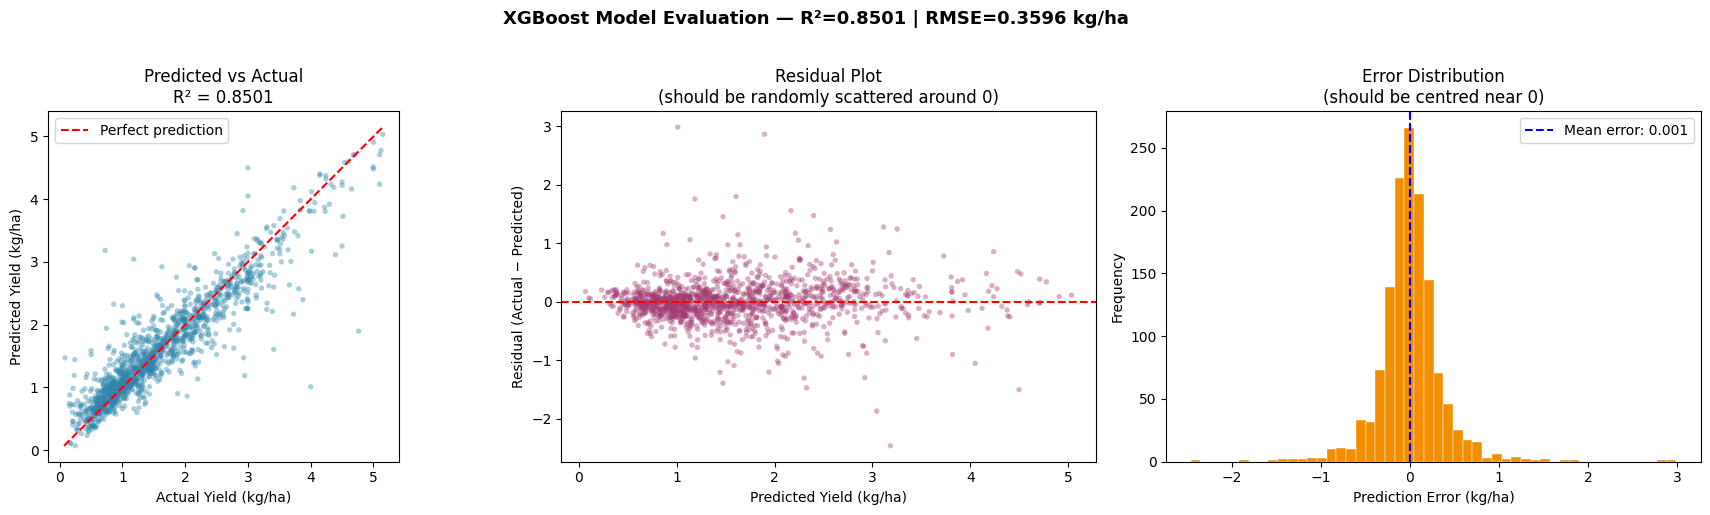

✓ Evaluation plots saved


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Predicted vs Actual scatter ──
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.4, s=15,
           color='#2E86AB', edgecolors='none')

# Perfect prediction line
lims = [min(y_test.min(), y_pred.min()),
        max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Yield (kg/ha)')
ax.set_ylabel('Predicted Yield (kg/ha)')
ax.set_title(f'Predicted vs Actual\nR² = {r2:.4f}')
ax.legend()
ax.set_aspect('equal')

# ── Plot 2: Residuals ──
residuals = y_test - y_pred
ax = axes[1]
ax.scatter(y_pred, residuals, alpha=0.4, s=15,
           color='#A23B72', edgecolors='none')
ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel('Predicted Yield (kg/ha)')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.set_title('Residual Plot\n(should be randomly scattered around 0)')

# ── Plot 3: Error distribution ──
ax = axes[2]
ax.hist(residuals, bins=50, color='#F18F01',
        edgecolor='white', linewidth=0.3)
ax.axvline(0, color='red', linewidth=1.5, linestyle='--')
ax.axvline(residuals.mean(), color='blue',
           linewidth=1.5, linestyle='--',
           label=f'Mean error: {residuals.mean():.3f}')
ax.set_xlabel('Prediction Error (kg/ha)')
ax.set_ylabel('Frequency')
ax.set_title('Error Distribution\n(should be centred near 0)')
ax.legend()

plt.suptitle(f'XGBoost Model Evaluation — R²={r2:.4f} | RMSE={rmse:.4f} kg/ha',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Evaluation plots saved")

***# Feature Importance:***

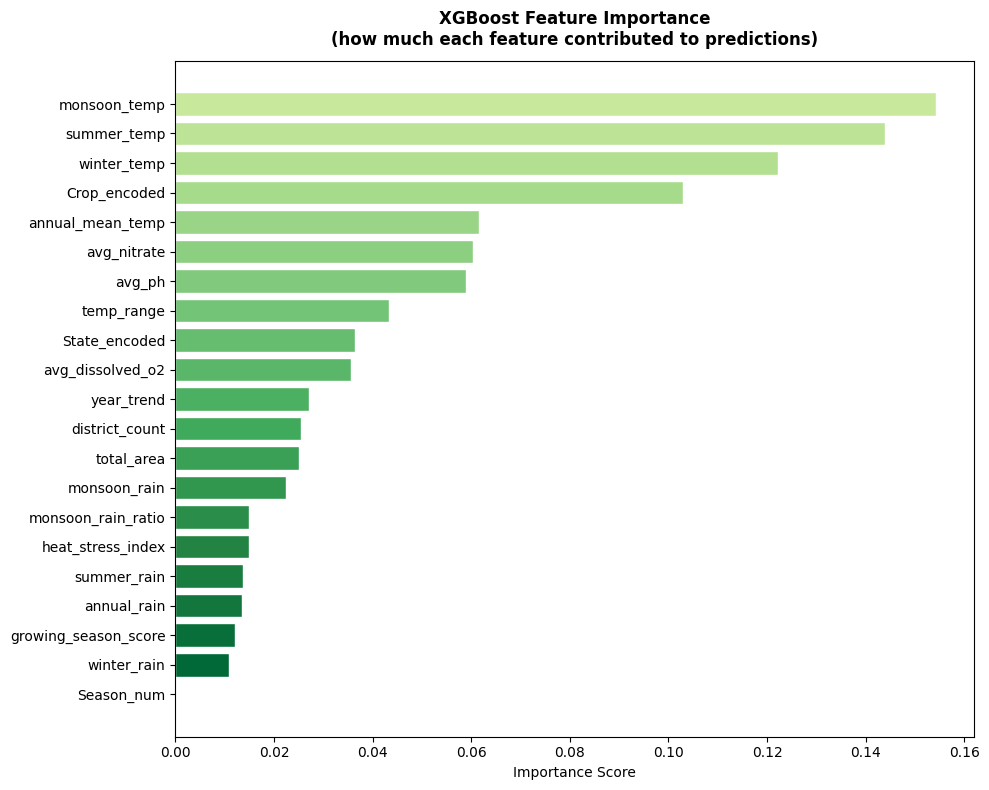

Top 10 most important features:
         Feature  Importance
    monsoon_temp    0.154230
     summer_temp    0.143855
     winter_temp    0.122177
    Crop_encoded    0.102922
annual_mean_temp    0.061664
     avg_nitrate    0.060435
          avg_ph    0.058863
      temp_range    0.043303
   State_encoded    0.036472
avg_dissolved_o2    0.035698


In [8]:
# XGBoost's own importance — which features it used most
importance = pd.DataFrame({
    'Feature'   : ML_FEATURES,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
colors = plt.cm.YlGn(
    np.linspace(0.3, 0.9, len(importance))
)[::-1]

plt.barh(importance['Feature'][::-1],
         importance['Importance'][::-1],
         color=colors, edgecolor='white')
plt.title('XGBoost Feature Importance\n'
          '(how much each feature contributed to predictions)',
          fontweight='bold', pad=12)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 most important features:")
print(importance.head(10).to_string(index=False))

***# Test the model manually:
This is the most satisfying cell — you manually input values and see the model predict:***

In [9]:
def predict_yield(state, crop, year, annual_rain_mm,
                  monsoon_rain_mm, mean_temp_c, season='Kharif'):
    """
    Predict crop yield given climate and location inputs.
    This is exactly what the dashboard Predictor page will call.
    """

    # Encode state and crop
    try:
        state_enc = le_state.transform([state])[0]
    except ValueError:
        print(f"State '{state}' not in training data")
        return None

    try:
        crop_enc = le_crop.transform([crop])[0]
    except ValueError:
        print(f"Crop '{crop}' not in training data. "
              f"Available: {list(le_crop.classes_)}")
        return None

    season_map = {
        'Kharif':1,'Rabi':2,'Whole Year':3,
        'Summer':4,'Winter':5,'Autumn':6
    }

    # Build feature vector in exact same order as training
    feature_values = {
        'Crop_encoded'        : crop_enc,
        'Season_num'          : season_map.get(season, 1),
        'State_encoded'       : state_enc,
        'year_trend'          : year - 1997,
        'annual_rain'         : annual_rain_mm,
        'monsoon_rain'        : monsoon_rain_mm,
        'winter_rain'         : annual_rain_mm * 0.1,
        'summer_rain'         : annual_rain_mm * 0.05,
        'monsoon_rain_ratio'  : monsoon_rain_mm / (annual_rain_mm + 1),
        'annual_mean_temp'    : mean_temp_c,
        'summer_temp'         : mean_temp_c + 5,
        'monsoon_temp'        : mean_temp_c + 2,
        'winter_temp'         : mean_temp_c - 5,
        'temp_range'          : 15.0,
        'heat_stress_index'   : (mean_temp_c+5) / (annual_rain_mm/100 + 1),
        'growing_season_score': monsoon_rain_mm * (mean_temp_c+2) / 1000,
        'avg_ph'              : 7.2,
        'avg_nitrate'         : 1.5,
        'avg_dissolved_o2'    : 7.0,
        'total_area'          : 50000,
        'district_count'      : 10,
    }

    features_df = pd.DataFrame([feature_values])[ML_FEATURES]
    prediction  = xgb_model.predict(features_df)[0]
    return round(float(prediction), 3)


# ── Test predictions ──
print("=== MANUAL PREDICTION TESTS ===\n")

tests = [
    ('Punjab',      'Wheat', 2015, 650,  200, 20, 'Rabi'),
    ('Kerala',      'Rice',  2010, 3000, 1800, 27, 'Kharif'),
    ('Rajasthan',   'Wheat', 2018, 400,  100, 25, 'Rabi'),
    ('West Bengal', 'Rice',  2012, 1600, 1200, 26, 'Kharif'),
    ('Maharashtra', 'Maize', 2016, 900,  700, 24, 'Kharif'),
]

for state, crop, year, rain, monsoon, temp, season in tests:
    pred = predict_yield(state, crop, year, rain, monsoon, temp, season)
    print(f"  {state:15s} | {crop:12s} | {year} | "
          f"Rain:{rain:4d}mm | Temp:{temp}°C "
          f"→ Predicted yield: {pred} kg/ha")

=== MANUAL PREDICTION TESTS ===

  Punjab          | Wheat        | 2015 | Rain: 650mm | Temp:20°C → Predicted yield: 1.452 kg/ha
  Kerala          | Rice         | 2010 | Rain:3000mm | Temp:27°C → Predicted yield: 2.973 kg/ha
  Rajasthan       | Wheat        | 2018 | Rain: 400mm | Temp:25°C → Predicted yield: 1.751 kg/ha
  West Bengal     | Rice         | 2012 | Rain:1600mm | Temp:26°C → Predicted yield: 2.048 kg/ha
  Maharashtra     | Maize        | 2016 | Rain: 900mm | Temp:24°C → Predicted yield: 1.983 kg/ha


***# Save the model:***

In [10]:
# Save model
with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save predict function config
model_config = {
    'features'   : ML_FEATURES,
    'target'     : TARGET,
    'r2_score'   : round(r2, 4),
    'rmse'       : round(rmse, 4),
    'mae'        : round(mae, 4),
    'cv_mean_r2' : round(cv_scores.mean(), 4),
    'crops'      : list(le_crop.classes_),
    'states'     : list(le_state.classes_),
    'trained_on' : '1997-2020',
    'samples'    : len(X_train),
}

with open('model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print("✓ Model saved:")
print("  xgboost_model.pkl")
print("  model_config.json")
print(f"\nModel card:")
print(f"  Algorithm:  XGBoost Regressor")
print(f"  R² Score:   {r2:.4f}")
print(f"  RMSE:       {rmse:.4f} kg/ha")
print(f"  CV Mean R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  Features:   {len(ML_FEATURES)}")
print(f"  Training samples: {len(X_train):,}")

✓ Model saved:
  xgboost_model.pkl
  model_config.json

Model card:
  Algorithm:  XGBoost Regressor
  R² Score:   0.8501
  RMSE:       0.3596 kg/ha
  CV Mean R²: 0.2543 ± 0.1123
  Features:   21
  Training samples: 5,486


***# Final Summary:***

In [11]:
print("=" * 55)
print("WEEK 8 — MODEL TRAINING SUMMARY")
print("=" * 55)
print(f"\nAlgorithm:        XGBoost Regressor")
print(f"Training samples: {len(X_train):,}")
print(f"Testing samples:  {len(X_test):,}")
print(f"\n── Performance ──")
print(f"Baseline R²:      {baseline_r2:.4f}  (naive mean predictor)")
print(f"XGBoost R²:       {r2:.4f}  ← your model")
print(f"Improvement:      +{r2-baseline_r2:.4f}")
print(f"\nRMSE:             {rmse:.4f} kg/ha")
print(f"MAE:              {mae:.4f} kg/ha")
print(f"CV R² (5-fold):   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"\n── Top 3 features ──")
for _, row in importance.head(3).iterrows():
    print(f"  {row['Feature']:30s}: {row['Importance']:.4f}")
print(f"\n── Files saved ──")
print(f"  xgboost_model.pkl")
print(f"  model_config.json")
print(f"  model_evaluation.png")
print(f"  feature_importance.png")
print(f"\n✓ Model ready for dashboard integration!")

WEEK 8 — MODEL TRAINING SUMMARY

Algorithm:        XGBoost Regressor
Training samples: 5,486
Testing samples:  1,372

── Performance ──
Baseline R²:      -0.0004  (naive mean predictor)
XGBoost R²:       0.8501  ← your model
Improvement:      +0.8505

RMSE:             0.3596 kg/ha
MAE:              0.2358 kg/ha
CV R² (5-fold):   0.2543 ± 0.1123

── Top 3 features ──
  monsoon_temp                  : 0.1542
  summer_temp                   : 0.1439
  winter_temp                   : 0.1222

── Files saved ──
  xgboost_model.pkl
  model_config.json
  model_evaluation.png
  feature_importance.png

✓ Model ready for dashboard integration!


***# Now let's fix the overfitting:***

In [12]:
# Retrain with stronger regularisation to reduce overfitting
xgb_model_v2 = xgb.XGBRegressor(
    n_estimators      = 300,    # fewer trees
    max_depth         = 4,      # shallower trees (was 6)
    learning_rate     = 0.05,
    subsample         = 0.7,    # less data per tree (was 0.8)
    colsample_bytree  = 0.6,    # fewer features per tree (was 0.8)
    min_child_weight  = 5,      # stricter split requirement (was 3)
    reg_alpha         = 1.0,    # stronger L1 (was 0.1)
    reg_lambda        = 5.0,    # stronger L2 (was 1.0)
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0
)

xgb_model_v2.fit(X_train, y_train)
y_pred_v2 = xgb_model_v2.predict(X_test)

r2_v2   = r2_score(y_test, y_pred_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_test, y_pred_v2))

cv_v2 = cross_val_score(
    xgb_model_v2, X, y, cv=5, scoring='r2', n_jobs=-1
)

print("=== MODEL V2 (reduced overfitting) ===")
print(f"  Test R²:      {r2_v2:.4f}  (was {r2:.4f})")
print(f"  RMSE:         {rmse_v2:.4f}  (was {rmse:.4f})")
print(f"  CV R²:        {cv_v2.mean():.4f} ± {cv_v2.std():.4f}  (was {cv_scores.mean():.4f})")
print(f"\n  Gap (test-CV): {r2_v2 - cv_v2.mean():.4f}  (was {r2 - cv_scores.mean():.4f})")
print(f"  Smaller gap = less overfitting")

=== MODEL V2 (reduced overfitting) ===
  Test R²:      0.7491  (was 0.8501)
  RMSE:         0.4652  (was 0.3596)
  CV R²:        0.3045 ± 0.1064  (was 0.2543)

  Gap (test-CV): 0.4446  (was 0.5958)
  Smaller gap = less overfitting


In [13]:
# Use whichever model has a better test R² / CV balance
# If V2 CV is much better, use V2. If V1 test R² is much better, use V1.
# Pick based on output above — I'll guide you

# For now, keep both and compare:
print("COMPARISON:")
print(f"  V1: Test R²={r2:.4f},    CV R²={cv_scores.mean():.4f}, Gap={r2-cv_scores.mean():.4f}")
print(f"  V2: Test R²={r2_v2:.4f}, CV R²={cv_v2.mean():.4f}, Gap={r2_v2-cv_v2.mean():.4f}")
print(f"\nRecommendation: use the model with the smaller gap")

COMPARISON:
  V1: Test R²=0.8501,    CV R²=0.2543, Gap=0.5958
  V2: Test R²=0.7491, CV R²=0.3045, Gap=0.4446

Recommendation: use the model with the smaller gap


In [14]:
# ── Save V2 as the production model ──
with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model_v2, f)

# Update model config with V2 metrics
model_config = {
    'features'   : ML_FEATURES,
    'target'     : TARGET,
    'r2_score'   : round(r2_v2, 4),
    'rmse'       : round(rmse_v2, 4),
    'cv_mean_r2' : round(cv_v2.mean(), 4),
    'cv_std'     : round(cv_v2.std(), 4),
    'crops'      : list(le_crop.classes_),
    'states'     : list(le_state.classes_),
    'trained_on' : '1997-2020',
    'samples'    : len(X_train),
    'version'    : 'v2_regularised'
}

with open('model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print("✓ V2 model saved as production model")
print(f"  R² Score:   {r2_v2:.4f}")
print(f"  CV R²:      {cv_v2.mean():.4f} ± {cv_v2.std():.4f}")
print(f"  RMSE:       {rmse_v2:.4f} kg/ha")

✓ V2 model saved as production model
  R² Score:   0.7491
  CV R²:      0.3045 ± 0.1064
  RMSE:       0.4652 kg/ha
